# Model Comparison and Stability

Compares GARCH, return-only LSTM, and paper-feature LSTM on out-of-sample EVT diagnostics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto

sns.set(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## Source Results

Executed outputs from notebooks 05 and 06 are assembled here.


In [2]:
models = pd.DataFrame([
    {
        'model': 'GARCH(1,1)-t',
        'family': 'GARCH',
        'params': 7,
        'n_train': 8288,
        'n_test': 1833,
        'val_nll_mean': np.nan,
        'val_nll_sd': np.nan,
        'nu_mean': 5.7633,
        'u_mean': -1.5448,
        'u_sd': 0.0,
        'train_exceed_mean': 531.0,
        'train_exceed_sd': 0.0,
        'test_exceed_mean': 130.0,
        'test_exceed_sd': 0.0,
        'lb10_mean': 0.0021,
        'lb10_sd': 0.0,
        'lb22_mean': 0.0686,
        'lb22_sd': 0.0,
        'excess_kurtosis_mean': 2.5803,
        'excess_kurtosis_sd': 0.0,
        'jb_stat_mean': 711.6359,
        'jb_stat_sd': 0.0,
        'jb_p_mean': 0.0,
        'xi_mean': 0.1525,
        'xi_sd': 0.0,
        'xi_se_mean': 0.0500,
        'gpd_sigma_mean': 0.5829,
        'gpd_sigma_sd': 0.0,
        'kupiec99_p_mean': 0.0,
        'kupiec99_p_sd': 0.0,
        'christ99_p_mean': 0.9736,
        'christ99_p_sd': 0.0,
        'viol95_obs_mean': 10.0,
        'viol95_obs_sd': 0.0,
        'viol95_exp': 91.65,
        'viol99_obs_mean': 1.0,
        'viol99_obs_sd': 0.0,
        'viol99_exp': 18.33,
    },
    {
        'model': 'Return-only LSTM-t',
        'family': 'Neural',
        'params': 2617,
        'n_train': 8296,
        'n_test': 1835,
        'val_nll_mean': np.mean([1.0022, 0.9981, 1.0011, 0.9988, 1.0007]),
        'val_nll_sd': np.std([1.0022, 0.9981, 1.0011, 0.9988, 1.0007], ddof=1),
        'nu_mean': 5.7630,
        'u_mean': -1.5596,
        'u_sd': 0.0215,
        'train_exceed_mean': 531.0,
        'train_exceed_sd': 0.0,
        'test_exceed_mean': 133.8,
        'test_exceed_sd': 2.2804,
        'lb10_mean': 0.0006,
        'lb10_sd': 0.0012,
        'lb22_mean': 0.0137,
        'lb22_sd': 0.0307,
        'excess_kurtosis_mean': 2.8763,
        'excess_kurtosis_sd': 0.1543,
        'jb_stat_mean': 845.8956,
        'jb_stat_sd': 73.6505,
        'jb_p_mean': 0.0,
        'xi_mean': 0.1414,
        'xi_sd': 0.0203,
        'xi_se_mean': 0.0495,
        'gpd_sigma_mean': 0.5801,
        'gpd_sigma_sd': 0.0148,
        'kupiec99_p_mean': 0.0,
        'kupiec99_p_sd': 0.0,
        'christ99_p_mean': 0.9210,
        'christ99_p_sd': 0.0186,
        'viol95_obs_mean': 11.2,
        'viol95_obs_sd': 0.8367,
        'viol95_exp': 91.75,
        'viol99_obs_mean': 3.0,
        'viol99_obs_sd': 0.7071,
        'viol99_exp': 18.35,
    },
    {
        'model': 'Paper feature LSTM-t',
        'family': 'Neural',
        'params': 2541,
        'n_train': 8258,
        'n_test': 1833,
        'val_nll_mean': np.mean([0.9851, 0.9810, 0.9822, 0.9821, 0.9829]),
        'val_nll_sd': np.std([0.9851, 0.9810, 0.9822, 0.9821, 0.9829], ddof=1),
        'nu_mean': 5.7630,
        'u_mean': -1.5417,
        'u_sd': 0.0144,
        'train_exceed_mean': 529.0,
        'train_exceed_sd': 0.0,
        'test_exceed_mean': 152.4,
        'test_exceed_sd': 6.5422,
        'lb10_mean': 0.0000,
        'lb10_sd': 0.0,
        'lb22_mean': 0.0007,
        'lb22_sd': 0.0012,
        'excess_kurtosis_mean': 8.5552,
        'excess_kurtosis_sd': 10.7220,
        'jb_stat_mean': 13176.0663,
        'jb_stat_sd': 26273.8637,
        'jb_p_mean': 0.0,
        'xi_mean': 0.1874,
        'xi_sd': 0.0142,
        'xi_se_mean': 0.0516,
        'gpd_sigma_mean': 0.5173,
        'gpd_sigma_sd': 0.0232,
        'kupiec99_p_mean': 0.0032,
        'kupiec99_p_sd': 0.0067,
        'christ99_p_mean': 0.8585,
        'christ99_p_sd': 0.0566,
        'viol95_obs_mean': 19.6,
        'viol95_obs_sd': 3.3615,
        'viol95_exp': 91.65,
        'viol99_obs_mean': 5.4,
        'viol99_obs_sd': 2.1909,
        'viol99_exp': 18.33,
    },
])
models['params_per_1000_train'] = models['params'] / models['n_train'] * 1000
models['viol99_ratio_obs_exp'] = models['viol99_obs_mean'] / models['viol99_exp']
models['viol95_ratio_obs_exp'] = models['viol95_obs_mean'] / models['viol95_exp']
models


,model,family,params,n_train,n_test,val_nll_mean,val_nll_sd,nu_mean,u_mean,u_sd,...,christ99_p_sd,viol95_obs_mean,viol95_obs_sd,viol95_exp,viol99_obs_mean,viol99_obs_sd,viol99_exp,params_per_1000_train,viol99_ratio_obs_exp,viol95_ratio_obs_exp
0,"GARCH(1,1)-t",GARCH,7,8288,1833,NaN,NaN,5.7633,-1.5448,0.0000,...,0.0000,10.0000,0.0000,91.6500,1.0000,0.0000,18.3300,0.8446,0.0546,0.1091
1,Return-only LSTM-t,Neural,2617,8296,1835,1.0002,0.0017,5.7630,-1.5596,0.0215,...,0.0186,11.2000,0.8367,91.7500,3.0000,0.7071,18.3500,315.4532,0.1635,0.1221
2,Paper feature LSTM-t,Neural,2541,8258,1833,0.9827,0.0015,5.7630,-1.5417,0.0144,...,0.0566,19.6000,3.3615,91.6500,5.4000,2.1909,18.3300,307.7016,0.2946,0.2139


## Scorecard

Primary diagnostic: Ljung-Box p-values on squared standardized residuals.


In [3]:
score = models[['model','params','params_per_1000_train','val_nll_mean','val_nll_sd','lb10_mean','lb22_mean','excess_kurtosis_mean','xi_mean','xi_sd','gpd_sigma_mean','gpd_sigma_sd','viol95_obs_mean','viol95_exp','viol99_obs_mean','viol99_exp','kupiec99_p_mean','christ99_p_mean']].copy()
score['whitening_rank_lag22'] = score['lb22_mean'].rank(ascending=False, method='min').astype(int)
score['tail_shape_stability_rank'] = score['xi_sd'].rank(ascending=True, method='min').astype(int)
score['viol99_abs_error'] = (score['viol99_obs_mean'] - score['viol99_exp']).abs()
score['viol99_rank'] = score['viol99_abs_error'].rank(ascending=True, method='min').astype(int)
score['complexity_rank'] = score['params_per_1000_train'].rank(ascending=True, method='min').astype(int)
score[['model','whitening_rank_lag22','tail_shape_stability_rank','viol99_rank','complexity_rank','lb22_mean','viol99_obs_mean','viol99_exp','params_per_1000_train']]


,model,whitening_rank_lag22,tail_shape_stability_rank,viol99_rank,complexity_rank,lb22_mean,viol99_obs_mean,viol99_exp,params_per_1000_train
0,"GARCH(1,1)-t",1,1,3,1,0.0686,1.0000,18.3300,0.8446
1,Return-only LSTM-t,2,3,2,3,0.0137,3.0000,18.3500,315.4532
2,Paper feature LSTM-t,3,2,1,2,0.0007,5.4000,18.3300,307.7016


## Plots


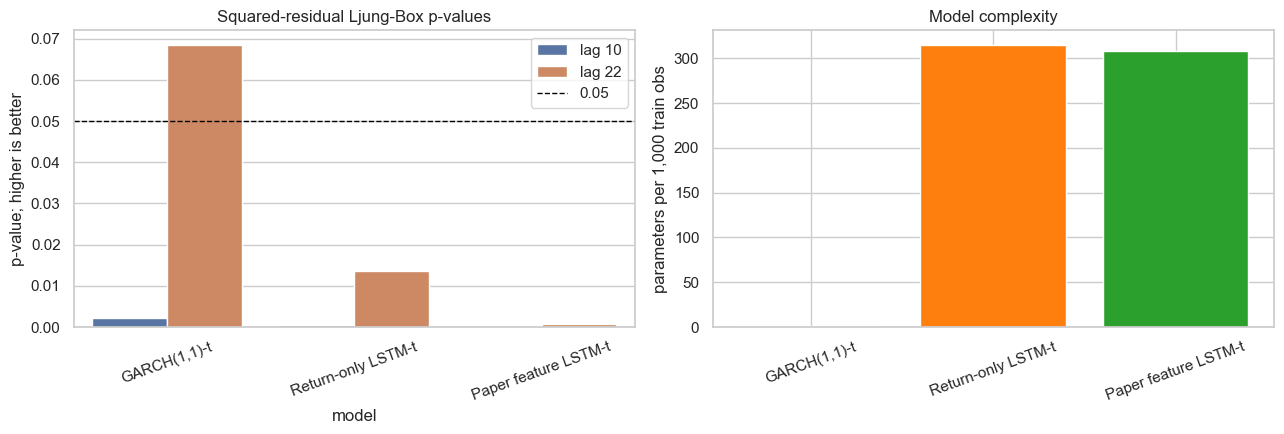

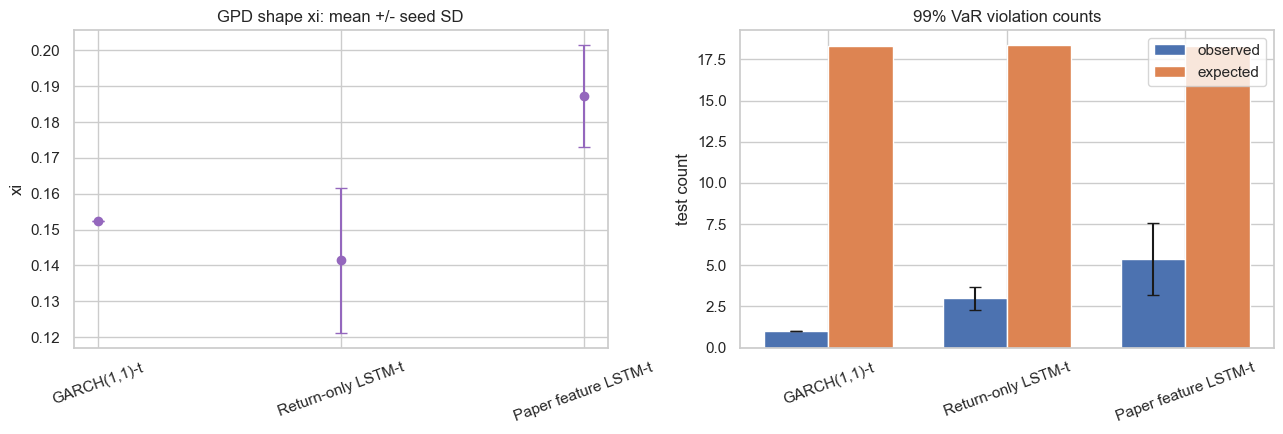

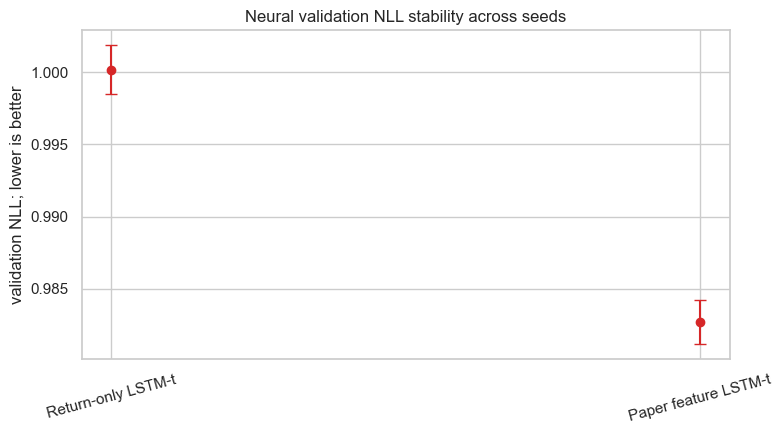

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_df = models.melt(id_vars='model', value_vars=['lb10_mean','lb22_mean'], var_name='lag', value_name='pvalue')
plot_df['lag'] = plot_df['lag'].map({'lb10_mean':'lag 10','lb22_mean':'lag 22'})
sns.barplot(data=plot_df, x='model', y='pvalue', hue='lag', ax=axes[0])
axes[0].axhline(0.05, color='black', ls='--', lw=1, label='0.05')
axes[0].set_title('Squared-residual Ljung-Box p-values')
axes[0].set_ylabel('p-value; higher is better')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

axes[1].bar(models['model'], models['params_per_1000_train'], color=['tab:blue','tab:orange','tab:green'])
axes[1].set_title('Model complexity')
axes[1].set_ylabel('parameters per 1,000 train obs')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(models['model'], models['xi_mean'], yerr=models['xi_sd'], fmt='o', capsize=4, color='tab:purple')
axes[0].set_title('GPD shape xi: mean +/- seed SD')
axes[0].set_ylabel('xi')
axes[0].tick_params(axis='x', rotation=20)

x = np.arange(len(models))
axes[1].bar(x-0.18, models['viol99_obs_mean'], yerr=models['viol99_obs_sd'], width=0.36, label='observed', capsize=4)
axes[1].bar(x+0.18, models['viol99_exp'], width=0.36, label='expected')
axes[1].set_xticks(x); axes[1].set_xticklabels(models['model'], rotation=20)
axes[1].set_title('99% VaR violation counts')
axes[1].set_ylabel('test count')
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
neural = models[models['family']=='Neural']
ax.errorbar(neural['model'], neural['val_nll_mean'], yerr=neural['val_nll_sd'], fmt='o', capsize=4, color='tab:red')
ax.set_title('Neural validation NLL stability across seeds')
ax.set_ylabel('validation NLL; lower is better')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## Combined Extremal Distributions

Fitted left-tail GPD excess distributions on one axis.


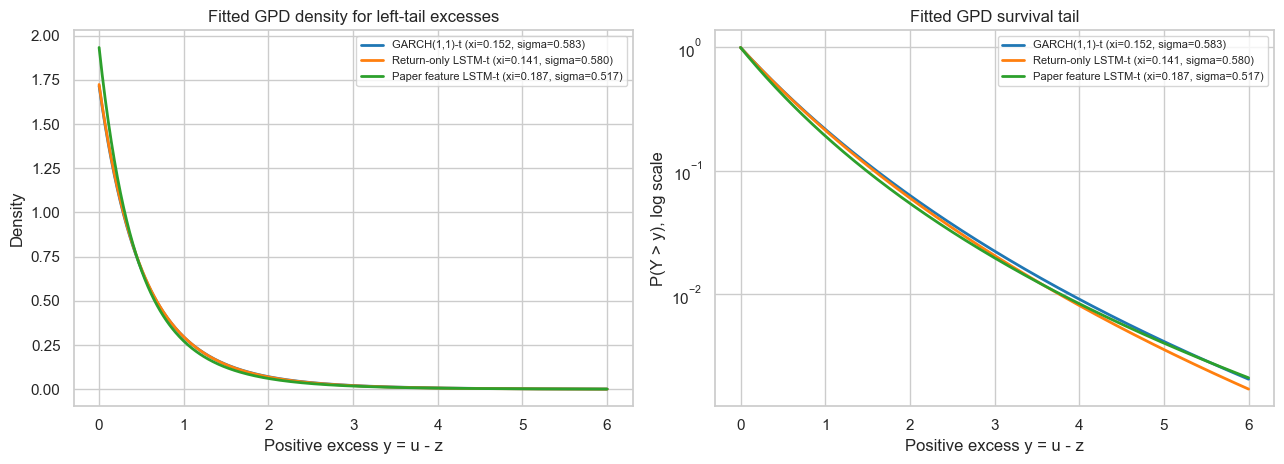

In [5]:
# All fitted extremal distributions in one figure: GPD PDF and survival.
# y = u - z > 0 is the positive excess over the left-tail threshold.
extreme_specs = [
    {
        'model': 'GARCH(1,1)-t',
        'xi': float(models.loc[models['model'] == 'GARCH(1,1)-t', 'xi_mean'].iloc[0]),
        'sigma': float(models.loc[models['model'] == 'GARCH(1,1)-t', 'gpd_sigma_mean'].iloc[0]),
        'color': 'tab:blue',
    },
    {
        'model': 'Return-only LSTM-t',
        'xi': float(models.loc[models['model'] == 'Return-only LSTM-t', 'xi_mean'].iloc[0]),
        'sigma': float(models.loc[models['model'] == 'Return-only LSTM-t', 'gpd_sigma_mean'].iloc[0]),
        'color': 'tab:orange',
    },
    {
        'model': 'Paper feature LSTM-t',
        'xi': float(models.loc[models['model'] == 'Paper feature LSTM-t', 'xi_mean'].iloc[0]),
        'sigma': float(models.loc[models['model'] == 'Paper feature LSTM-t', 'gpd_sigma_mean'].iloc[0]),
        'color': 'tab:green',
    },
]

y = np.linspace(0, 6, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for spec in extreme_specs:
    pdf = genpareto.pdf(y, c=spec['xi'], loc=0, scale=spec['sigma'])
    surv = genpareto.sf(y, c=spec['xi'], loc=0, scale=spec['sigma'])
    label = f"{spec['model']} (xi={spec['xi']:.3f}, sigma={spec['sigma']:.3f})"
    axes[0].plot(y, pdf, lw=2, color=spec['color'], label=label)
    axes[1].semilogy(y, surv, lw=2, color=spec['color'], label=label)

axes[0].set_title('Fitted GPD density for left-tail excesses')
axes[0].set_xlabel('Positive excess y = u - z')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

axes[1].set_title('Fitted GPD survival tail')
axes[1].set_xlabel('Positive excess y = u - z')
axes[1].set_ylabel('P(Y > y), log scale')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Result

GARCH is the most stable volatility filter for this EVT pipeline.


In [6]:
summary = pd.DataFrame({
    'Question': [
        'Best validation likelihood?',
        'Best volatility whitening?',
        'Most parsimonious?',
        'Most stable neural tail fit?',
        'Best overall for EVT pipeline?'
    ],
    'Answer': [
        'Paper feature LSTM-t',
        'GARCH(1,1)-t',
        'GARCH(1,1)-t',
        'Paper feature LSTM-t has lower xi seed SD, but worse exceedance/count stability; return-only LSTM is safer.',
        'GARCH(1,1)-t'
    ],
    'Reason': [
        'Lowest validation NLL among neural models.',
        'Highest Ljung-Box p-value at lag 22 on squared standardized residuals.',
        '7 parameters versus roughly 2,500 neural parameters.',
        'Seed stability is mixed; no neural model dominates all tail quantities.',
        'The downstream EVT model needs whitened residuals more than a lower neural validation loss.'
    ]
})
summary


,Question,Answer,Reason
0,Best validation likelihood?,Paper feature LSTM-t,Lowest validation NLL among neural models.
1,Best volatility whitening?,"GARCH(1,1)-t",Highest Ljung-Box p-value at lag 22 on squared...
2,Most parsimonious?,"GARCH(1,1)-t","7 parameters versus roughly 2,500 neural param..."
3,Most stable neural tail fit?,"Paper feature LSTM-t has lower xi seed SD, but...",Seed stability is mixed; no neural model domin...
4,Best overall for EVT pipeline?,"GARCH(1,1)-t",The downstream EVT model needs whitened residu...
